# 02 - Analyze
Runs diagnostics on model_df, fits the mixed effects regression, and builds the forest plots and ICC calculations.

# Imports

In [1]:
# Libraries needed for diagnostics, the mixed effects regression, and the forest plot
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import forestplot as fp # builds the final forest plot
from statsmodels.stats.outliers_influence import variance_inflation_factor # checks collinearity between predictors
from patsy import dmatrix # builds the design matrix used for the VIF check
import statsmodels.api as sm # lowess smoother in the functional form check
import statsmodels.formula.api as smf # fits the mixed effects regression

# Functions

In [2]:
def clean_label(v):
    if v.startswith("C(motivo)") or v.startswith("C(mode_group)") or v.startswith("C(sexo)"):
        return v.split("T.")[1].rstrip("]")
    return {
        "job_housing_ratio_z": "Job-housing ratio",
        "jobs_accessible_per_household_z": "Jobs accessible (40 min)",
        "qt_auto_z": "Household cars",
        "idade_z": "Age",
    }.get(v, v)

In [3]:
def categorize(v):
    if v in ["job_housing_ratio_z", "jobs_accessible_per_household_z"]:
        return "Jobs/Housing Distribution"
    if v.startswith("C(mode_group)"):
        return "Transportation Access"
    if v in ["qt_auto_z"]:
        return "Trade-off Variables"
    if v.startswith("C(motivo)") or v.startswith("C(sexo)") or v == "idade_z":
        return "Demographic Controls"
    return "Other"

# Load model data

In [4]:
# Load the cleaned, feature engineered dataset saved by the merge notebook
model_df = pd.read_pickle("final_project_data/interim/model_df.pkl")

# Same predictor/outcome/group setup used to build model_df in the merge notebook
num_vars = ["job_housing_ratio", "jobs_accessible_per_household", "qt_auto", "idade"]
cat_vars = ["sexo", "motivo", "mode_group"]
outcome = "duracao"
group = "zona"

print(f"Loaded model_df: {model_df.shape}")
print(model_df.dtypes[num_vars + cat_vars + [outcome, group]])

Loaded model_df: (112913, 155)
job_housing_ratio                 float64
jobs_accessible_per_household     float64
qt_auto                           float64
idade                             float64
sexo                             category
motivo                           category
mode_group                       category
duracao                           float64
zona                              float64
dtype: object


Before fitting the model, I looked at summary statistics and histograms of each continuous predictor and the outcome variable, to check for extreme outliers or an unusual shape.

In [5]:
model_df[num_vars + [outcome]].describe()

,job_housing_ratio,jobs_accessible_per_household,qt_auto,idade,duracao
count,112726.000000,112726.000000,112803.000000,112913.000000,112913.000000
mean,0.521271,24.671763,0.834597,37.921798,32.536121
std,0.867323,31.309621,0.765564,19.852217,30.187191
min,0.019118,0.180993,0.000000,1.000000,0.000000
25%,0.157187,3.576450,0.000000,22.000000,10.000000
50%,0.262268,8.341590,1.000000,38.000000,20.000000
75%,0.548037,42.597756,1.000000,53.000000,43.000000
max,9.618496,185.870052,9.000000,102.000000,270.000000


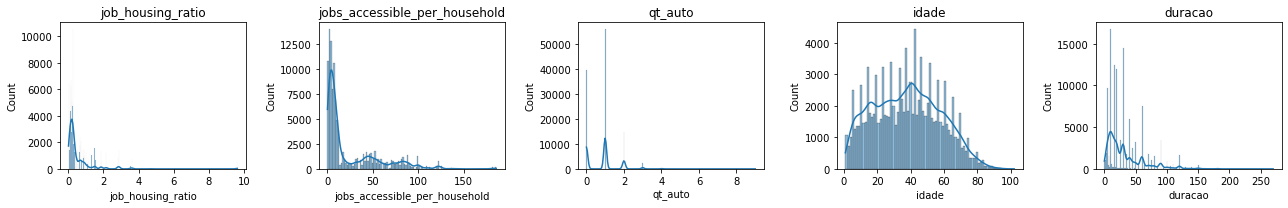

In [6]:
fig, axes = plt.subplots(1, len(num_vars) + 1, figsize=(18, 3))
for ax, v in zip(axes, num_vars + [outcome]):
    sns.histplot(model_df[v], ax=ax, kde=True)
    ax.set_title(v)
plt.tight_layout()

Variance inflation factor (VIF) check:

In [7]:
# Build the design matrix to calculate VIF
design_str = "job_housing_ratio_z + jobs_accessible_per_household_z + qt_auto_z + idade_z"
X = dmatrix(design_str, model_df, return_type="dataframe")

In [8]:
# Calculate the VIF for every column in the design matrix
vif_df = pd.DataFrame({
    "variable": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

In [9]:
print(vif_df)

                          variable       VIF
0                        Intercept  1.000000
1              job_housing_ratio_z  1.433239
2  jobs_accessible_per_household_z  1.463988
3                        qt_auto_z  1.025402
4                          idade_z  1.021608


Plotting each predictor against trip duration with a lowess smoothed curve on to check how reasonable the regression looks.

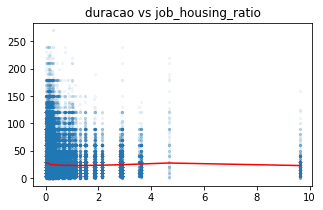

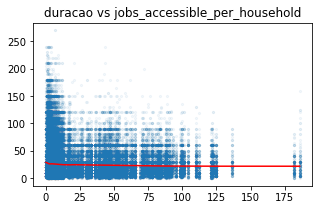

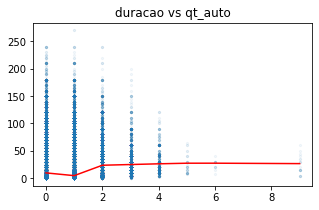

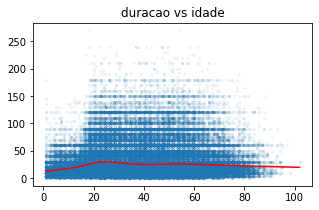

In [10]:
# For each continuous predictor, plot the raw data as a scatterplot and overlay a lowess smoothed curve
for v in num_vars:
    sub = model_df[[v, outcome]].dropna()
    lowess = sm.nonparametric.lowess(sub[outcome], sub[v], frac=0.3)
    plt.figure(figsize=(5,3))
    plt.scatter(sub[v], sub[outcome], alpha=0.05, s=5)
    plt.plot(lowess[:,0], lowess[:,1], color="red")
    plt.title(f"duracao vs {v}")
    plt.show()

Checking the number of zones and how many trips are in each so a reasonable number of zones, the random intercept grouping variable, are used

In [11]:
zone_sizes = model_df.groupby(group).size() # How many trips fall into each zone

In [12]:
print(f"Number of zones: {zone_sizes.shape[0]}")

Number of zones: 492


In [13]:
print(zone_sizes.describe())

count    492.000000
mean     229.497967
std      107.486834
min       56.000000
25%      166.000000
50%      205.500000
75%      249.250000
max      848.000000
dtype: float64


In [14]:
print(f"Zones with < 5 obs: {(zone_sizes < 5).sum()}") # How many zones have fewer than 5 trips

Zones with < 5 obs: 0


The model below is fit with smf.mixedlm, using zone as the grouping variable for a random intercept.

In [15]:
# Predict trip duration from the four standardized continuous predictors and the three categorical predictors
formula = ("duracao ~ job_housing_ratio_z + jobs_accessible_per_household_z + qt_auto_z + idade_z "
"+ C(sexo) + C(motivo) + C(mode_group)")

In [16]:
# Drop rows with missing values in the outcome, group, or predictor columns
model_data = model_df.dropna(subset=["duracao", group] + num_vars + cat_vars)

In [17]:
# Fit the mixed effects model
mixed_model = smf.mixedlm(formula, model_data, groups=model_data[group])
result = mixed_model.fit()

In [18]:
print(result.summary())

                       Mixed Linear Model Regression Results
Model:                     MixedLM         Dependent Variable:         duracao     
No. Observations:          112616          Method:                     REML        
No. Groups:                491             Scale:                      476.6111    
Min. group size:           56              Log-Likelihood:             -507618.3212
Max. group size:           848             Converged:                  Yes         
Mean group size:           229.4                                                   
-----------------------------------------------------------------------------------
                                      Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
-----------------------------------------------------------------------------------
Intercept                             33.453    0.285 117.218 0.000  32.894  34.012
C(sexo)[T.Feminino]                   -0.376    0.136  -2.774 0.006  -0.642  -0.110
C(sexo)[T.Não r

In [19]:
# Check whether the model converged to a stable solution
print("Converged:", result.converged)

Converged: True


Extracting the coefficients out of the fitted model's results.

In [20]:
coefs = result.params.drop("Group Var", errors="ignore")
conf_int = result.conf_int() # Confidence interval
conf_int = conf_int.drop("Group Var", errors="ignore")

In [21]:
# Plain table with one row per predictor
forest_df = pd.DataFrame({
    "variable": coefs.index,
    "coef": coefs.values,
    "ci_low": conf_int[0].values,
    "ci_high": conf_int[1].values,
    "pval": result.pvalues.drop("Group Var", errors="ignore").values
})

In [22]:
# Remove the intercept row, since it jusr represents the baseline for the reference categories
forest_df = forest_df[forest_df["variable"] != "Intercept"]

In [23]:
print(forest_df)

                                variable       coef     ci_low    ci_high  \
1                    C(sexo)[T.Feminino]  -0.376077  -0.641771  -0.110384   
2               C(sexo)[T.Não respondeu]  -1.062030  -7.699246   5.575186   
3         C(motivo)[T.Assuntos Pessoais]  -6.984707  -7.604162  -6.365253   
4                   C(motivo)[T.Compras] -11.505936 -12.117794 -10.894077   
5           C(motivo)[T.Escola/Educação] -12.672169 -13.066451 -12.277887   
6     C(motivo)[T.Médico/Dentista/Saúde]  -2.122052  -2.749473  -1.494631   
7          C(motivo)[T.Procurar Emprego]   0.799709  -2.306068   3.905485   
8   C(motivo)[T.Recreação/Visitas/Lazer]  -5.974951  -6.615800  -5.334103   
9                  C(motivo)[T.Refeição] -11.884096 -13.220919 -10.547273   
10        C(motivo)[T.Trabalho Comércio]  -3.553311  -4.043306  -3.063316   
11       C(motivo)[T.Trabalho Indústria]   3.512582   2.929340   4.095823   
12                  C(mode_group)[T.Bus]  21.541452  21.083567  21.999336   

Converting techinical names into readable labels for the forest plot.

In [24]:
forest_df["label"] = forest_df["variable"].apply(clean_label) # Apply clean_label to every row

Tagging each predictor to a potentially policy relevant category. 

In [25]:
forest_df["group"] = forest_df["variable"].apply(categorize) # Apply categorize to every row

Keeping demographic controls (sex, trip purpose, age) in the fitted model but drops them from what gets plotted for readability.

In [26]:
display_df = forest_df[forest_df["group"] != "Demographic Controls"].copy()
print(display_df[["label", "group", "coef"]])

                       label                      group       coef
12                       Bus      Transportation Access  21.541452
13           Car (passenger)      Transportation Access  -2.314336
14                      Moto      Transportation Access  -9.728504
15                     Other      Transportation Access   4.443136
16              Rail transit      Transportation Access  44.270686
17          School/chartered      Transportation Access   4.725014
18                  Taxi/app      Transportation Access  -0.323592
19                 Walk/Bike      Transportation Access -12.632319
20         Job-housing ratio  Jobs/Housing Distribution   0.413853
21  Jobs accessible (40 min)  Jobs/Housing Distribution  -4.426571
22            Household cars        Trade-off Variables   0.125713


Splitting into two panels for plotting: mode categorical effects and the two zone-level continuous variables with car ownership.

In [27]:
mode_df = display_df[display_df["group"] == "Transportation Access"].copy() # Only the Transportation Access (mode group) rows
policy_df = display_df[display_df["group"] != "Transportation Access"].copy() # Jobs/housing distribution and trade-off variables

Building the forest plots

In [28]:
# These in the figure captions to report the size of the data the model was fit on
n_zones = model_df[group].nunique()
n_trips = len(model_df)

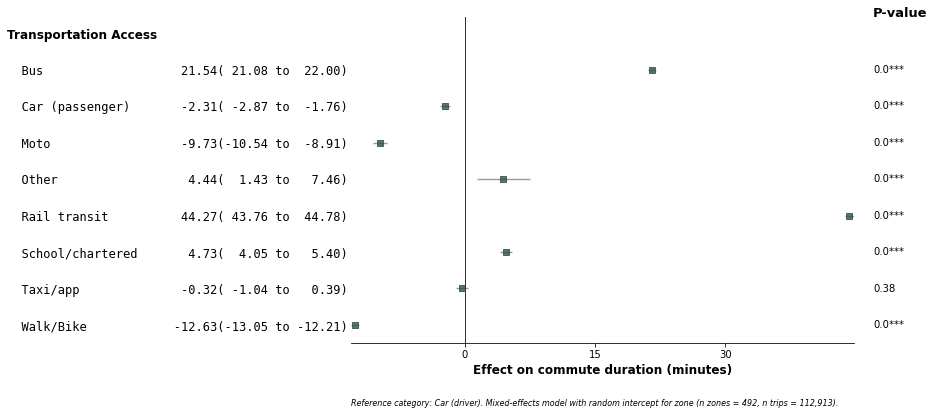

In [29]:
fig1 = fp.forestplot(
    mode_df, estimate="coef", ll="ci_low", hl="ci_high",
    varlabel="label", groupvar="group", pval="pval",
    decimal_precision=2, xlabel="Effect on commute duration (minutes)",
    figsize=(9, 6),
)
plt.figtext(
    0.5, -0.02,
    f"Reference category: Car (driver). Mixed-effects model with random intercept for zone "
    f"(n zones = {n_zones}, n trips = {n_trips:,}).",
    ha="center", fontsize=8, style="italic", wrap=True
)
plt.savefig("transportation_access.png", bbox_inches="tight", dpi=200)
plt.show()

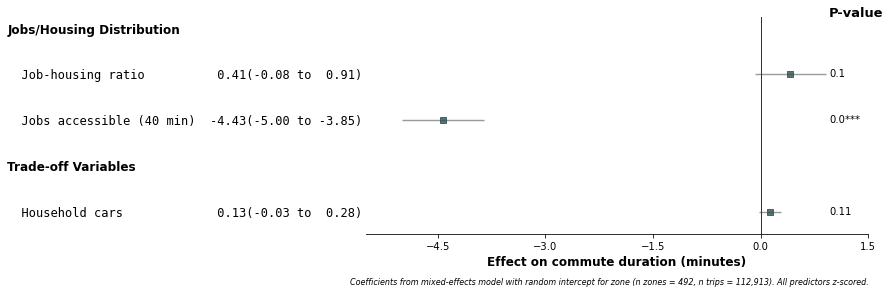

In [30]:
fig2 = fp.forestplot(
    policy_df, estimate="coef", ll="ci_low", hl="ci_high",
    varlabel="label", groupvar="group", pval="pval",
    decimal_precision=2, xlabel="Effect on commute duration (minutes)",
    figsize=(9, 4),
)
plt.xlim(-5.5, 1.5)
plt.figtext(
    0.5, -0.05,
    f"Coefficients from mixed-effects model with random intercept for zone "
    f"(n zones = {n_zones}, n trips = {n_trips:,}). All predictors z-scored.",
    ha="center", fontsize=8, style="italic", wrap=True
)
plt.savefig("job_tradeoff.png", bbox_inches="tight", dpi=200)
plt.show()

Calculating the intraclass correlation (ICC): zone level variance that remains after the other predictors have already explained their share and how much zone alone explains before controlling (unconditional).

In [31]:
icc = result.cov_re.iloc[0,0] / (result.cov_re.iloc[0,0] + result.scale)
print(f"ICC: {icc:.3f}")

ICC: 0.046


In [32]:
null_formula = "duracao ~ 1"
null_model = smf.mixedlm(null_formula, model_df, groups=model_df[group])
null_result = null_model.fit()

icc_null = null_result.cov_re.iloc[0,0] / (null_result.cov_re.iloc[0,0] + null_result.scale)
print(f"Uncond. ICC: {icc_null:.3f}")

Uncond. ICC: 0.061
